Visualizing Embeddings


#### Project environment setup

- Load credentials and relevant Python Libraries

In [1]:
from utils import authenticate
credentials, PROJECT_ID = authenticate() #Get credentials and project ID

In [2]:
REGION = 'us-central1'

#### Enter project details

In [3]:
# Import and initialize the Vertex AI Python SDK

import vertexai
vertexai.init(project=PROJECT_ID, 
              location=REGION, 
              credentials = credentials)

## Embeddings capture meaning

In [4]:
in_1 = "Missing flamingo discovered at swimming pool"

in_2 = "Sea otter spotted on surfboard by beach"

in_3 = "Baby panda enjoys boat ride"


in_4 = "Breakfast themed food truck beloved by all!"

in_5 = "New curry restaurant aims to please!"


in_6 = "Python developers are wonderful people"

in_7 = "TypeScript, C++ or Java? All are great!" 


input_text_lst_news = [in_1, in_2, in_3, in_4, in_5, in_6, in_7]

> Note: the "textembedding-gecko@001" was retired in April 2025, instead it is recommended to use the "text-embedding-004" model. Check the [documentation](https://docs.cloud.google.com/vertex-ai/generative-ai/docs/learn/model-versions) for more details.

In [5]:
import numpy as np
from vertexai.language_models import TextEmbeddingModel


embedding_model = TextEmbeddingModel.from_pretrained("text-embedding-004")

/Users/olaoluadisa/Documents/WEBDEV1/webdev/code files/codefiles/llm/llm_venv/lib/python3.13/site-packages/vertexai/_model_garden/_model_garden_models.py:278: UserWarning: This feature is deprecated as of June 24, 2025 and will be removed on June 24, 2026. For details, see https://cloud.google.com/vertex-ai/generative-ai/docs/deprecations/genai-vertexai-sdk.
  warning_logs.show_deprecation_warning()


- Get embeddings for all pieces of text.
- Store them in a 2D NumPy array (one row for each embedding).

In [6]:
embeddings = []
for input_text in input_text_lst_news:
    emb = embedding_model.get_embeddings(
        [input_text])[0].values
    embeddings.append(emb)
    
embeddings_array = np.array(embeddings) 

In [7]:
print("Shape: " + str(embeddings_array.shape))
print(embeddings_array)

Shape: (7, 768)
[[ 0.02803496 -0.00299724 -0.01659381 ... -0.01121059 -0.00519713
  -0.02044056]
 [ 0.00485451  0.03049659 -0.01399871 ... -0.01616582 -0.03072107
   0.01834136]
 [ 0.03935665 -0.03734451 -0.06938332 ... -0.02096844 -0.01913369
   0.02881981]
 ...
 [ 0.00716709 -0.05124414  0.01775808 ...  0.00892509 -0.00407107
   0.00254001]
 [ 0.03583142 -0.05428725  0.00165318 ... -0.01935553  0.04669554
   0.02359349]
 [ 0.05533755 -0.0237293  -0.03609464 ... -0.03040388  0.02278006
   0.01252656]]


#### Reduce embeddings from 768 to 2 dimensions for visualization
- We'll use principal component analysis (PCA).
- You can learn more about PCA in [this video](https://www.coursera.org/learn/unsupervised-learning-recommenders-reinforcement-learning/lecture/73zWO/reducing-the-number-of-features-optional) from the Machine Learning Specialization. 

In [8]:
from sklearn.decomposition import PCA


# Perform PCA for 2D visualization
PCA_model = PCA(n_components = 2)
PCA_model.fit(embeddings_array)
new_values = PCA_model.transform(embeddings_array)

In [9]:
print("Shape: " + str(new_values.shape))
print(new_values)

Shape: (7, 2)
[[ 0.49533001  0.17530328]
 [ 0.47394037  0.16537099]
 [ 0.34864739  0.11626409]
 [-0.01331229 -0.5433861 ]
 [-0.22950727 -0.56127286]
 [-0.4674816   0.36944202]
 [-0.60761662  0.27827859]]


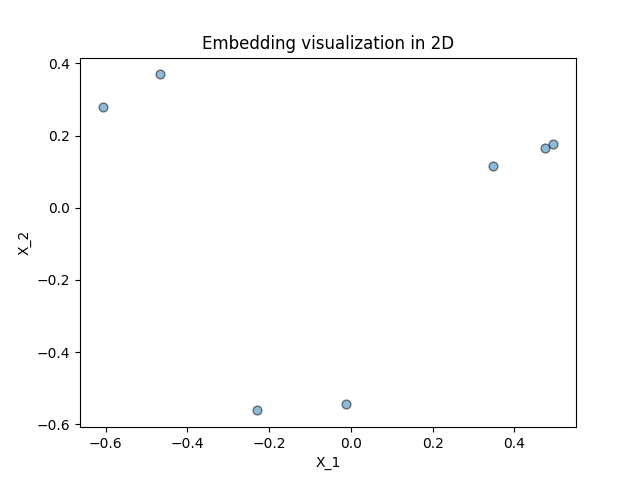

In [10]:
import matplotlib.pyplot as plt
import mplcursors
%matplotlib ipympl

from utils import plot_2D
plot_2D(new_values[:,0], new_values[:,1], input_text_lst_news)

#### Embeddings and Similarity
- Plot a heat map to compare the embeddings of sentences that are similar and sentences that are dissimilar.

In [11]:
in_1 = """He couldn’t desert 
          his post at the power plant."""

in_2 = """The power plant needed 
          him at the time."""

in_3 = """Cacti are able to 
          withstand dry environments.""" 

in_4 = """Desert plants can 
          survive droughts.""" 

input_text_lst_sim = [in_1, in_2, in_3, in_4]

In [12]:
embeddings = []
for input_text in input_text_lst_sim:
    emb = embedding_model.get_embeddings([input_text])[0].values
    embeddings.append(emb)
    
embeddings_array = np.array(embeddings) 

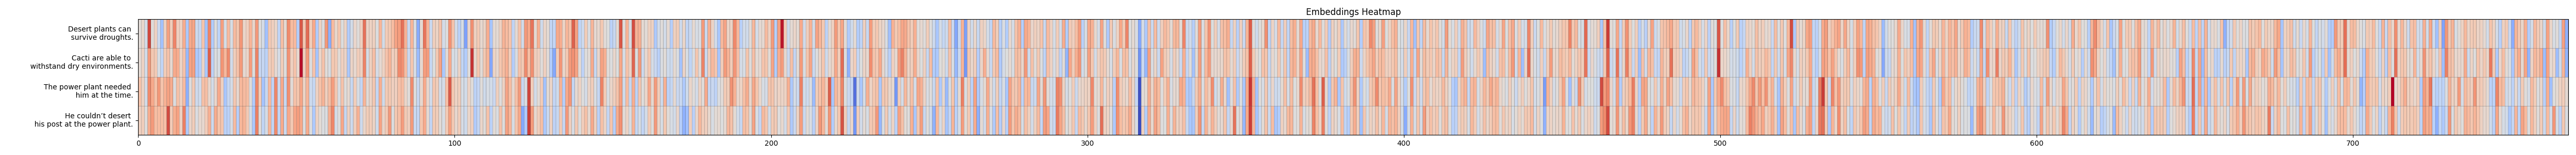

In [13]:
from utils import plot_heatmap

y_labels = input_text_lst_sim

# Plot the heatmap
plot_heatmap(embeddings_array, y_labels = y_labels, title = "Embeddings Heatmap")

Note: the heat map won't show everything because there are 768 columns to show.  To adjust the heat map with your mouse:
- Hover your mouse over the heat map.  Buttons will appear on the left of the heatmap.  Click on the button that has a vertical and horizontal double arrow (they look like axes).
- Left click and drag to move the heat map left and right.
- Right click and drag up to zoom in.
- Right click and drag down to zoom out.

#### Compute cosine similarity
- The `cosine_similarity` function expects a 2D array, which is why we'll wrap each embedding list inside another list.
- You can verify that sentence 1 and 2 have a higher similarity compared to sentence 1 and 4, even though sentence 1 and 4 both have the words "desert" and "plant".

In [14]:
from sklearn.metrics.pairwise import cosine_similarity

In [15]:
def compare(embeddings,idx1,idx2):
    return cosine_similarity([embeddings[idx1]],[embeddings[idx2]])

In [16]:
print(in_1)
print(in_2)
print(compare(embeddings,0,1))

He couldn’t desert 
          his post at the power plant.
The power plant needed 
          him at the time.
[[0.78397453]]


In [17]:
print(in_1)
print(in_4)
print(compare(embeddings,0,3))

He couldn’t desert 
          his post at the power plant.
Desert plants can 
          survive droughts.
[[0.33994118]]
